# Training a Transformer for BARRA-R2
This notebook builds on the 'Accessing BARRA-R2' and 'Building pipelines for BARRA2' notebook. 

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import dask.distributed
import cartopy.crs as ccrs

# Load PET specific modules and NCI settings
import pyearthtools
import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
import site_archive_nci

import torch
import torch.nn as nn
import torch.optim as optim

import warnings
warnings.filterwarnings('ignore')

In [12]:
# Set random seed for reproducibility
torch.manual_seed(42)

# Autodetect GPU and use if possible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## Main
Now we can start with the main code.

First, lets start a dask client to help with computation.

In [4]:
client = dask.distributed.Client(n_workers = 4, threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 4
Total threads: 4,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35415,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33319,Total threads: 1
Dashboard: /proxy/36423/status,Memory: 15.75 GiB
Nanny: tcp://127.0.0.1:43509,


And then we can define the list of variables we want, as well as a mapping between the names in BARRA2 and ERA5.

Based on these variables lists, we can then build all the data accessors we need.

In [13]:
varlist_hourly_instant = [
    'tas', # surface temperature
    'uas', # 10m u-winds
    'vas', # 10m v-winds
    'psl', # mean sea level pressure
    'prw', # water vapour path,
]

varlist_hourly_instant_plev = [
    'ta500', # temperature at 500hPa
    'ua500', # u-wind at 500hPa
    'va500', # v-winds at 500hPa
    'omega500', # pressure velocity at 500hPa
    'hus500', # specific humidity at 500hPa
    'zg500', # geopotential at 500hPa
]

varlist_hourly_averaged = [
    'pr', # hourly average precipitation
    'clt', # hourly average cloud cover
    'rsdt', # hourly average TOA Incident Shortwave Radiation
    'rsds', # hourly average shortwave down surface
    'rsut', # hourly average TOA outgoing shortwave
    'rlus', # hourly averaged longwave up surface
    'rlds', # hourly average longwave down surface
    'rlut', # hourly average TOA outgoing longwave
]

# The full varlist is
varlist = varlist_hourly_instant + varlist_hourly_averaged + varlist_hourly_instant_plev

In [14]:
barra2era_map = {
    'tas': '2t',
    'ta500': 't',
    'uas': 'u10n',
    'ua500': 'u',
    'vas': 'v10n',
    'va500': 'v',
    'omega500': 'w',
    'hus500': 'q',
    'ps': 'sp',
    'psl': 'msl',
    'prw': 'tcw',
    'pr': 'tp',
    'clt': 'tcc',
    'zg500': 'z',
    # following https://www.ecmwf.int/sites/default/files/elibrary/2015/18490-radiation-quantities-ecmwf-model-and-mars.pdf
    'rsdt': 'tisr', # J m-2
    'rsds': 'ssrd', # J m-2
    'rsut': 'tsr', # tisr - tsr, J m-2
    'rlus': 'str', # strd - str, J m-2
    'rlds': 'strd', # J m-2
    'rlut': 'ttr', # J m-2
}

In [15]:
# BARRA-R2 accessor
barra2_hinstant = petdata.archive.BARRA_V2(varlist_hourly_instant+varlist_hourly_instant_plev, domain_id='AUS-11', frequency='1hr')

# In ERA5, accumulations are over the hour (the accumulation/processing period)
# ending at the validity date/time, while in BARRA2 the valid time is in the middle
# of the aggregation period.
# To make both match, we round the valid time in BARRA2 to the neearst larger hour (e.g., 00:30UTC becomes 01:00UTC)
# For this I created a transformation to be used when creating the accessor
barra2_haveraged = petdata.archive.BARRA_V2(
    varlist_hourly_averaged,
    domain_id='AUS-11',
    frequency='1hr',
)

# ERA5 accessor
era5_surface = petdata.archive.ERA5([barra2era_map[key] for key in varlist_hourly_instant + varlist_hourly_averaged], product='reanalysis')
era5_plev = petdata.archive.ERA5([barra2era_map[key] for key in varlist_hourly_instant_plev], product='reanalysis')

## Build the pipeline
Building on the previous notebook of accessing barra2 data and plotting climatologies and histograms we know what variable transformations are needed to match up between BARRA2 and ERA5.

And using the transformation and operation classes we have defined and the beginning of the notebook, we can now do the same things using PET pipelines.

As in the previous notebook, we need to re-grid ERA5 to match the BARRA-R2 horizontal resolution. This is only needed because we want to plot some time steps for comparisons after setting up out pipelines. Those comparison plots will help us verify that we have setup the pipelines correctly and they behave as we expect.

For the re-gridding we need to define the reference grid (ref_grid) as below.

In [16]:
ref_grid = barra2_hinstant['1979-01-01 00:00']['tas'].squeeze()
ref_grid

<xarray.DataArray 'tas' (height: 2, latitude: 646, longitude: 1082)> Size: 11MB
dask.array<getitem, shape=(2, 646, 1082), dtype=float64, chunksize=(1, 104, 208), chunktype=numpy.ndarray>
Coordinates:
    time       datetime64[ns] 8B 1979-01-01
  * latitude   (latitude) float64 5kB -57.97 -57.86 -57.75 ... 12.76 12.87 12.98
  * longitude  (longitude) float64 9kB 88.48 88.59 88.7 ... 207.2 207.3 207.4
  * height     (height) float64 16B 1.5 10.0
    crs        int32 4B ...
Attributes:
    long_name:      Near-Surface Air Temperature
    standard_name:  air_temperature
    units:          K
    cell_methods:   time: point (interval: 1H)
    grid_mapping:   crs

In [17]:
def mean_height(dataset):
    return dataset.mean('height')

In [18]:
variable_rename = {
    'ta': 'ta500',
    'ua': 'ua500',
    'va': 'va500',
    'omega': 'omega500',
    'hus': 'hus500',
    'zg': 'zg500',
}

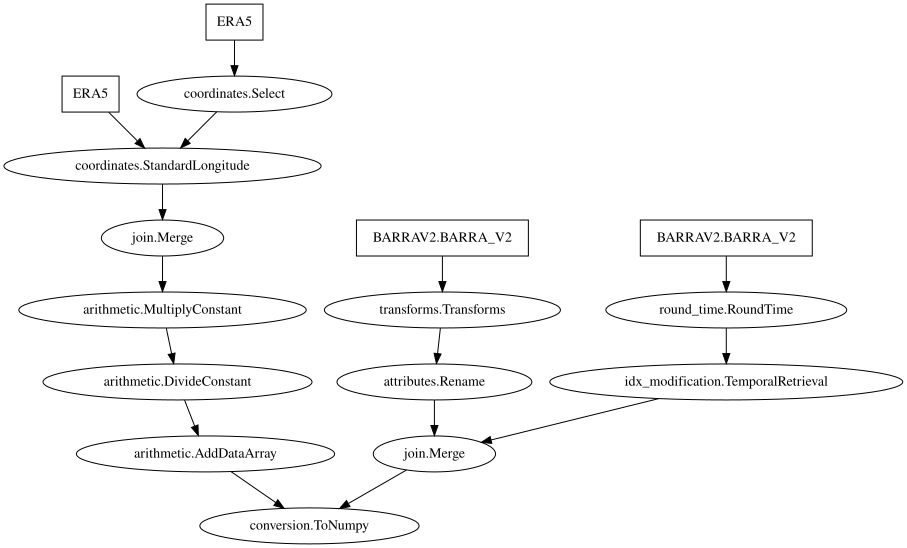

In [100]:
pipe_era5_surface = petpipe.Pipeline(
    era5_surface,
)

pipe_era5_plev = petpipe.Pipeline(
    era5_plev,
    petdata.transforms.coordinates.Select({"level":500})
)

pipe_era5 = petpipe.Pipeline(
    (pipe_era5_surface, pipe_era5_plev),
    petdata.transforms.coordinates.StandardLongitude(type="0-360"),
    petpipe.operations.xarray.Merge(),
    petdata.transforms.arithmetic.MultiplyConstant(
        tcc=100,
        tp=1000
    ),
    petdata.transforms.arithmetic.DivideConstant(
        tp=3600,
        z=9.81,
        tisr=3600,
        ssrd=3600,
        strd=3600,
        ttr=-3600,
        tsr=-3600, 
        str=-3600
    ),
    petdata.transforms.arithmetic.AddDataArray(
        tsr='tisr',
        str='strd'
    )
)

pipe_barra_instant = petpipe.Pipeline(
    barra2_hinstant,
    petpipe.operations.Transforms(mean_height),
    petdata.transforms.attributes.Rename(
            {var: variable_rename[var] for var in variable_rename.keys()}
        )
)

pipe_barra_average = petpipe.Pipeline(
    barra2_haveraged,
    # The updating of the valid time for the averaged variables
    # is a two-step process. First, we ceil the times to the nearest hour
    # (e.g., 00:30, becomes 01:00) and then we have to tell PET, 
    # that the old index, with hour 00, now belongs to hour 01.
    # In PET terms this means shift the index back by one (-1) and retrieve 1 time step
    petpipe.operations.xarray.RoundTime("H", 'ceil'),
    petpipe.modifications.idx_modification.TemporalRetrieval((-1,1)),
)

pipe_barra = petpipe.Pipeline(
    (pipe_barra_instant, pipe_barra_average),
    petpipe.operations.xarray.Merge(),
)

pipe = petpipe.Pipeline(
    (pipe_era5, pipe_barra),
    # pipe_barra,
    # This time we want the pipe to return a tuple rather than ERA5 and 
    # BARRA-R2 merged into the same dataset
    # petpipe.operations.xarray.join.InterpLike(ref_grid),
    petpipe.operations.xarray.conversion.ToNumpy(),
    # petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    iterator=petpipe.iterators.DateRange(1990, 1995, interval='1 hour')
)
pipe

In [101]:
ipipe = iter(pipe)

In [102]:
n = next(ipipe)
n

TypeError: len() of unsized object

## Plotting and verification
Now that we have defined the individual pipelines and combined all the individual pipelines in the final pipeline, we plot the first time step to confirm that it works as we expect it to!

Please note that some differences between ERA5 and BARRA-R2 are to be expected. In particulay for variables that are very sensitive to the higher horizontal resolution of BARRA-R2, such as precipitation (pr), vertical velocity (omega500), cloud cover (clt) and some radiation fields that are influenced by clouds (rsds, rsut).

The differences are also expected to be larger than in the previous notebook because we are looking at snapshots in time rather than monthly averaged fields.

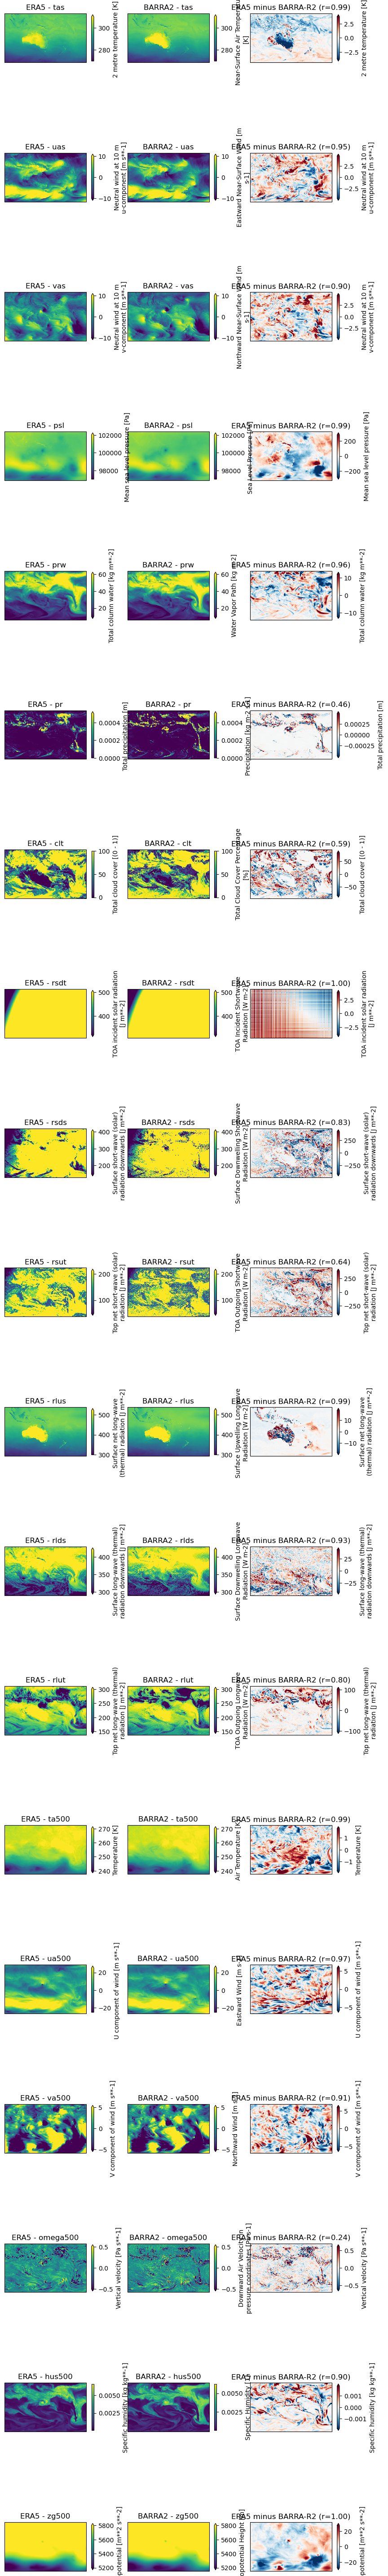

In [12]:
nrows = len(varlist)
fig, axs = plt.subplots(nrows,3, figsize=((10,4*nrows)),subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

# Let's define the colour range for easier comparison
vminmax = {
    'tas': (270,310),
    'ta500': (240,270),
    'uas': (-10,10),
    'ua500': (-25,25),
    'vas': (-10,10),
    'va500': (-5,5),
    'omega500': (-0.5,0.5),
    'huss': (None, None),
    'hus500': (None, None),
    'ps': (75000,101000),
    'psl': (97000,102000),
    'prw': (10,60),
    'pr': (0,5e-4),
    'clt': (0,100),
    'rsdt': (320,500),
    'rsds': (150,400),
    'rsut': (50,210),
    'rlus': (300,520),
    'rlds': (300,420),
    'rlut': (150,300),
    'zg500': (5200, 5800),
}

# Plot all variable comparisons
for i, var in enumerate(varlist):
    # Get the first sample
    sample = pipe['1979-01-01 01:00']
    a = sample[var].squeeze()
    b = sample[barra2era_map[var]].squeeze()
    r = xr.corr(
        a,
        b
    ).values
    b.plot.pcolormesh(ax=axs[i,0], vmin=vminmax[var][0], vmax=vminmax[var][1], transform=ccrs.PlateCarree(), cbar_kwargs=dict(shrink=0.4))
    a.plot.pcolormesh(ax=axs[i,1], vmin=vminmax[var][0], vmax=vminmax[var][1], transform=ccrs.PlateCarree(), cbar_kwargs=dict(shrink=0.4))
    (b-a).plot.pcolormesh(ax=axs[i,2], robust=True, transform=ccrs.PlateCarree(), cbar_kwargs=dict(shrink=0.4))
    axs[i,0].set_title(f"ERA5 - {var}")
    axs[i,1].set_title(f"BARRA2 - {var}")
    axs[i,2].set_title(f"ERA5 minus BARRA-R2 (r={r:.2f})")